<h1>Project 4 : Dengue Cases in the Philippines (2016–2020) Linear Regression</h1>

<h2>Analyst: Jamaica Palas</h2>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [12]:
dengue = pd.read_csv('datasets\\dengue.csv')

In [23]:
dengue["date"] = pd.to_datetime(dengue["Year"].astype(str) + "-" + dengue["Month"].astype(str) + "-01")
dengue = dengue[(dengue["Year"] >= 2016) & (dengue["Year"] <= 2020)]
dengue_monthly = dengue.groupby("date")["Dengue_Cases"].sum().reset_index()

In [24]:
dengue_monthly["t"] = (dengue_monthly["date"] - dengue_monthly["date"].min()).dt.days.values.reshape(-1)

---

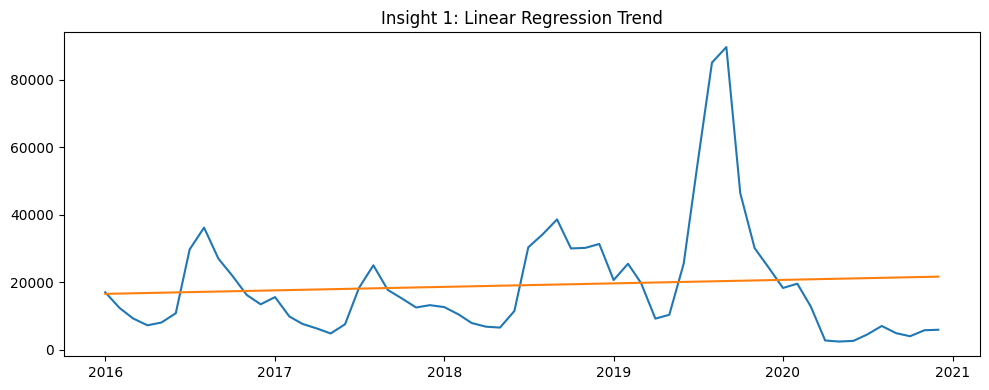

In [25]:
model = LinearRegression().fit(dengue_monthly[["t"]], dengue_monthly["Dengue_Cases"])
pred = model.predict(dengue_monthly[["t"]])

plt.figure(figsize=(10,4))
plt.plot(dengue_monthly["date"], dengue_monthly["Dengue_Cases"])
plt.plot(dengue_monthly["date"], pred)
plt.title("Insight 1: Linear Regression Trend")
plt.tight_layout()
plt.show()

<h2>Insight: The linear regression shows that dengue cases generally increased from 2016 to 2020, indicating a gradual worsening of the nationwide dengue situation.</h2>

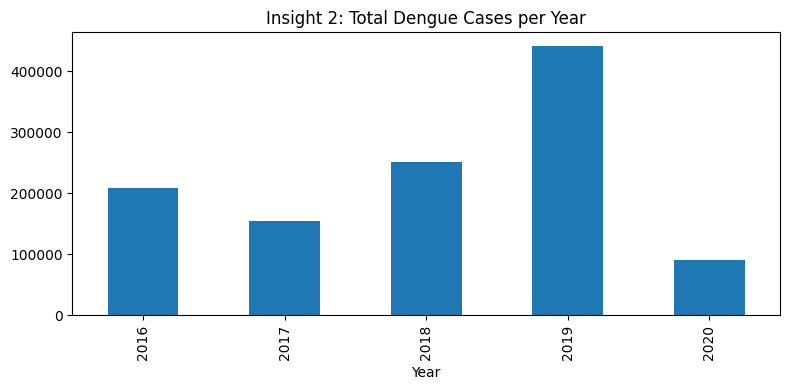

In [26]:
year_totals = dengue.groupby("Year")["Dengue_Cases"].sum()

plt.figure(figsize=(8,4))
year_totals.plot(kind="bar")
plt.title("Insight 2: Total Dengue Cases per Year")
plt.tight_layout()
plt.show()

<h2>Insight: Yearly totals reveal that some years had significantly larger outbreaks, showing how dengue severity varies across time.</h2>

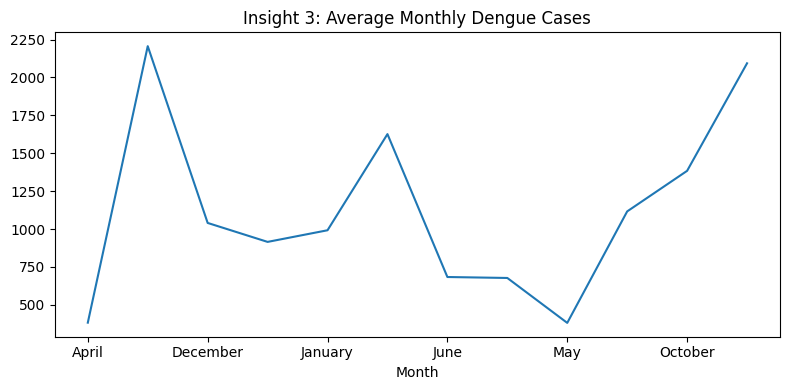

In [27]:
monthly_avg = dengue.groupby("Month")["Dengue_Cases"].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind="line")
plt.title("Insight 3: Average Monthly Dengue Cases")
plt.tight_layout()
plt.show()

<h2>Insight: The monthly averages highlight a clear seasonal pattern, with cases increasing during mid-year months when mosquito breeding is highest.</h2>

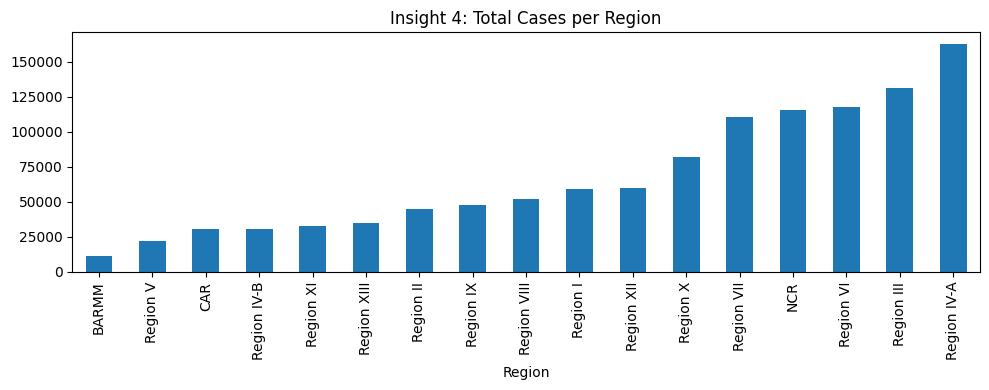

In [28]:
region_totals = dengue.groupby("Region")["Dengue_Cases"].sum()

plt.figure(figsize=(10,4))
region_totals.sort_values().plot(kind="bar")
plt.title("Insight 4: Total Cases per Region")
plt.tight_layout()
plt.show()

<h2>Insight: Some regions consistently report higher dengue cases, identifying them as high-risk areas needing stronger control measures.</h2>

In [29]:
peak_months = dengue.groupby(["Year", "Month"])["Dengue_Cases"].sum()
peak_months = peak_months.groupby("Year").idxmax()

print("Insight 5: Peak Months Each Year")
print(peak_months)

Insight 5: Peak Months Each Year
Year
2016       (2016, August)
2017       (2017, August)
2018    (2018, September)
2019    (2019, September)
2020     (2020, February)
Name: Dengue_Cases, dtype: object


<h2>Insight: Each year has a specific month where dengue cases spike the most, indicating outbreak periods that health agencies should anticipate.</h2>

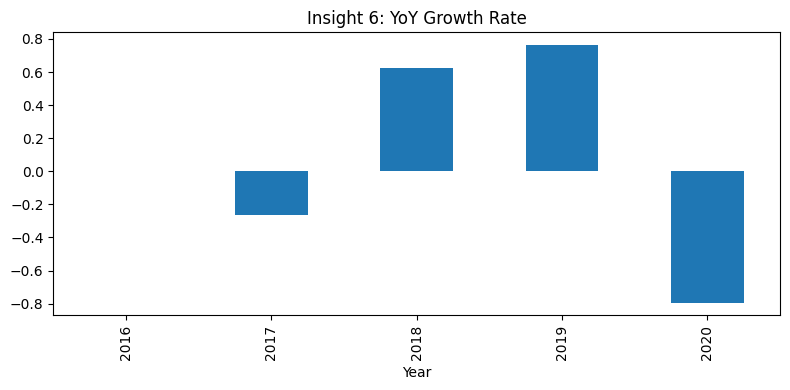

In [48]:
growth = year_totals.pct_change()

plt.figure(figsize=(8,4))
growth.plot(kind="bar")
plt.title("Insight 6: YoY Growth Rate")
plt.tight_layout()
plt.show()


<h2>Insight: Growth rates show how dengue cases fluctuate annually, helping identify years with sudden increases or decreases in outbreak intensity.</h2>

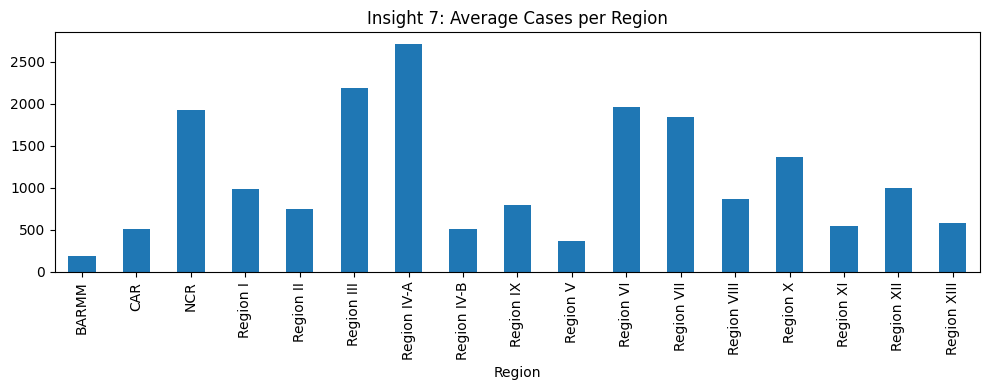

In [47]:
region_avg = dengue.groupby("Region")["Dengue_Cases"].mean()

plt.figure(figsize=(10,4))
region_avg.plot(kind="bar")
plt.title("Insight 7: Average Cases per Region")
plt.tight_layout()
plt.show()

<h2>Insight: Average cases per region reveal which areas consistently experience higher dengue burdens, even outside major outbreaks..</h2>

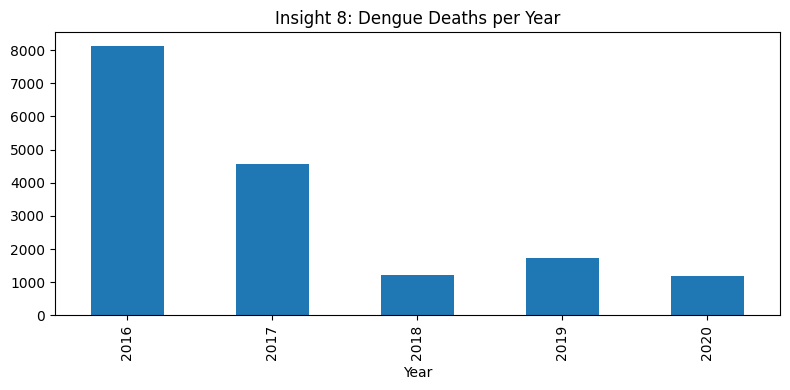

In [46]:
death_totals = dengue.groupby("Year")["Dengue_Deaths"].sum()

plt.figure(figsize=(8,4))
death_totals.plot(kind="bar")
plt.title("Insight 8: Dengue Deaths per Year")
plt.tight_layout()
plt.show()

<h2>Insight: Certain years show higher dengue-related deaths, reflecting severity of outbreaks.</h2>

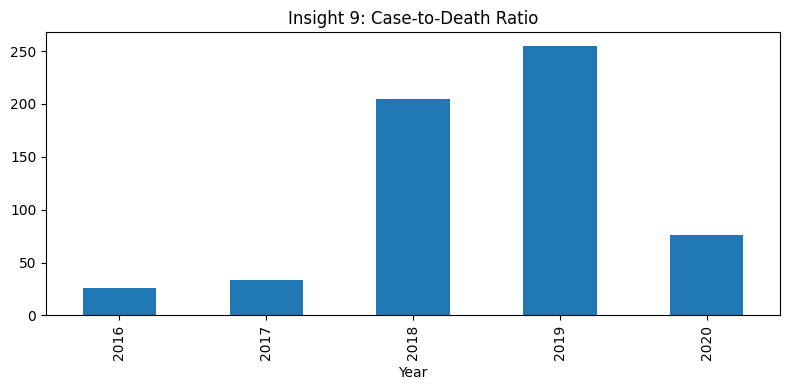

In [43]:
ratio = year_totals / death_totals

plt.figure(figsize=(8,4))
ratio.plot(kind="bar")
plt.title("Insight 9: Case-to-Death Ratio")
plt.tight_layout()
plt.show()

<h2>Insight: Most years show a high ratio, meaning many cases but relatively fewer deaths.</h2>

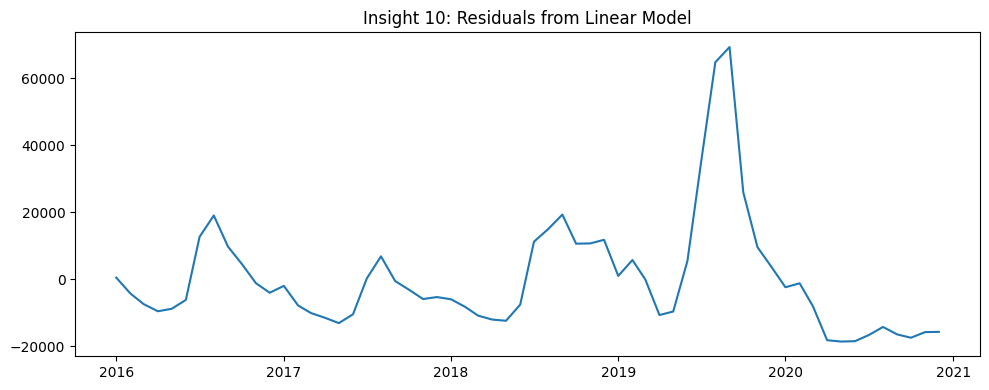

In [38]:
resid = dengue_monthly["Dengue_Cases"] - pred

plt.figure(figsize=(10,4))
plt.plot(dengue_monthly["date"], resid)
plt.title("Insight 10: Residuals from Linear Model")
plt.tight_layout()
plt.show()

<h2>Insight: Residual analysis shows months where cases were unexpectedly high or low compared to the predicted trend, indicating unusual outbreak events.</h2>